<a href="https://colab.research.google.com/github/BigDave07/Stock-Price-Prediction-LSTM/blob/main/Stock_Price_LSTMipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance
!pip install tensorflow

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM

np.random.seed(42)
tf.random.set_seed(42)

Download NVDA Data

We’ll grab 5 years of daily prices and keep the Close (common forecasting target)

In [3]:

ticker = "NVDA"
df = yf.download(ticker, period="5y", interval="1d")
df = df[["Close"]].dropna()
df.tail()

/tmp/ipython-input-3799914265.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="5y", interval="1d")
[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,NVDA
Date,
2025-11-03,206.880005
2025-11-04,198.690002
2025-11-05,195.210007
2025-11-06,188.080002
2025-11-07,188.149994


Train/Test Split by Time

No shuffling in time series: we train on the past and test on the future.

In [4]:
# scale to [0,1] for stable training
scaler = MinMaxScaler(feature_range=(0, 1))
close_scaled = scaler.fit_transform(df[["Close"]]).astype(np.float32)

# helper to create (X, y) windows
def make_sequences(series, window=30):
    X, y = [], []
    for i in range(window, len(series)):
        X.append(series[i-window:i, 0])  # previous 30 closes
        y.append(series[i, 0])           # next close
    X = np.array(X)
    y = np.array(y)
    # reshape to [samples, timesteps, features] for LSTM
    X = X.reshape((X.shape[0], X.shape[1], 1))
    return X, y

WINDOW = 30
X_all, y_all = make_sequences(close_scaled, window=WINDOW)

# 80% train, 20% test (strictly by time)
split_idx = int(len(X_all) * 0.8)
X_train, X_test = X_all[:split_idx], X_all[split_idx:]
y_train, y_test = y_all[:split_idx], y_all[split_idx:]

len(X_train), len(X_test), df.index[split_idx+WINDOW]



(980, 246, Timestamp('2024-11-14 00:00:00'))

Build the LSTM Model

Two stacked LSTM layers learn short- and longer-term patterns; Dense(1) predicts the next price.

In [5]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW, 1)),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss="mse")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

Train (Watch Loss Decrease)
We’ll train with a small batch and keep validation on the test split for a quick sanity check

Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - loss: 0.0143 - val_loss: 0.0089
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0013 - val_loss: 0.0019
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0010 - val_loss: 0.0018
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 9.0435e-04 - val_loss: 0.0020
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 7.4531e-04 - val_loss: 0.0037
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0010 - val_loss: 0.0040
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 8.7979e-04 - val_loss: 0.0016
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 8.8029e-04 - val_loss: 0.0026
Epoch 9/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 9.2742e-04 - val_loss: 0.0030
Epoch 10/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 7.3252e-04 - val_loss: 0.0017
Epoch 11/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 6.8182e-04 - val_loss: 0.0024
Epoch 12/20
31/31 ━━━━━━━━━━━━━━━━━

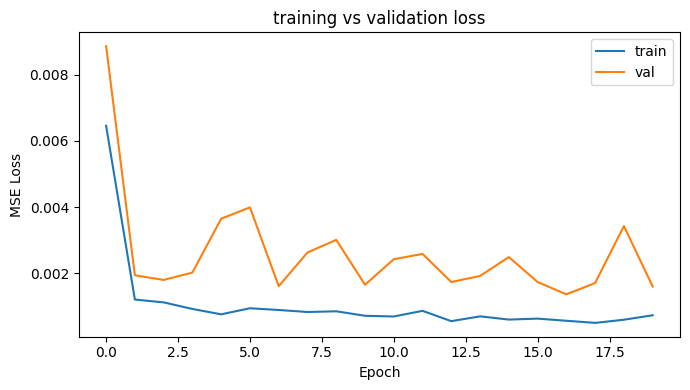

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    verbose=1
)

#Plot training vs Validation
plt.figure(figsize=(7,4))
plt.plot(history.history['loss'], label="train")
plt.plot(history.history["val_loss"], label= "val")
plt.title("training vs validation loss")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.legend(); plt.tight_layout()
plt.savefig("nvda LSTM loss")
plt.show()

Evaluate & Visualize Predictions

We’ll predict the test set, inverse-scale back to dollars, and compute RMSE/MAE. Then plot Actual vs Predicted.

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
NVDA Test RMSE: $144.55 | MAE: $141.70


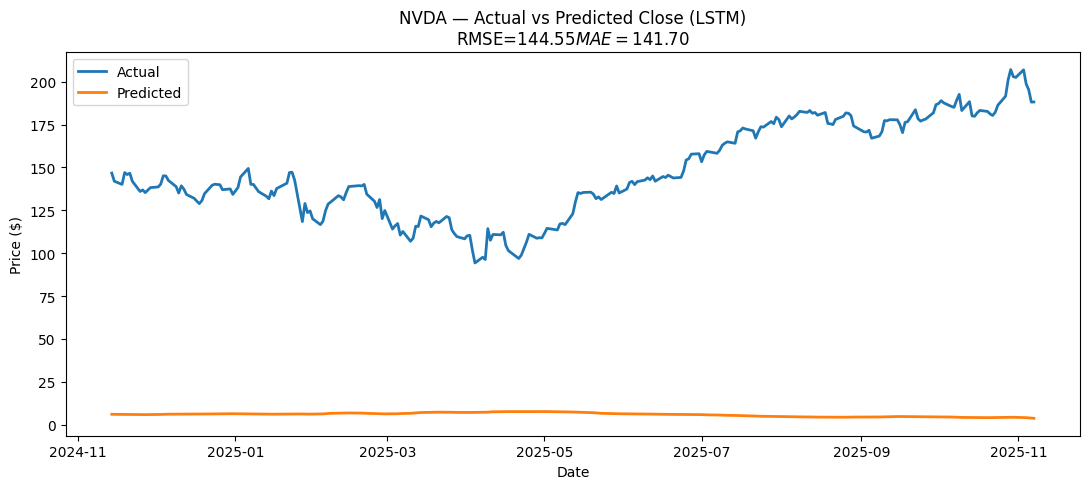

In [6]:
# Predict on test set
pred_test_scaled = model.predict(X_test)
# inverse scale to original dollars
pred_test = scaler.inverse_transform(pred_test_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

# Metrics
rmse = sqrt(mean_squared_error(y_test_actual, pred_test))
mae  = mean_absolute_error(y_test_actual, pred_test)
print(f"NVDA Test RMSE: ${rmse:.2f} | MAE: ${mae:.2f}")

# Build aligned index for plotting (test segment dates)
test_dates = df.index[WINDOW+split_idx : WINDOW+split_idx+len(y_test_actual)]

plt.figure(figsize=(11,5))
plt.plot(test_dates, y_test_actual, label="Actual", linewidth=2)
plt.plot(test_dates, pred_test, label="Predicted", linewidth=2)
plt.title(f"NVDA — Actual vs Predicted Close (LSTM)\nRMSE=${rmse:.2f}  MAE=${mae:.2f}")
plt.xlabel("Date"); plt.ylabel("Price ($)")
plt.legend(); plt.tight_layout();
plt.savefig("nvda LSTM.png")
plt.show()



Forecast the Next Day

Use the last 30 days to predict tomorrow’s closing price.

In [7]:
# Take the last window from the entire scaled series
last_window = close_scaled[-WINDOW:].reshape(1, WINDOW, 1)
next_scaled = model.predict(last_window)[0, 0]
next_price = scaler.inverse_transform([[next_scaled]])[0, 0]
print(f"Predicted next closing price for {ticker}: ${next_price:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Predicted next closing price for NVDA: $3.66
